## Creating a Linear Regression Model

### Discovery

Welcome new data analyst contractor, to Ethical Oil Inc. Whilst on your generous and extremely interesting 30 second induction, your IT systems have been fully set up, tested and everything is working perfectly. <br><br>
As your first task, you have been tasked with trying to determine if there is a linear relationship between the cost of oil and the S&P 500 valuation. You will use a linear regression model to establish if any relationship exists and if so, how oil prices are impacted by stock market fluctuations. Data has already been sourced by the ever efficient and humble management team.

First we will import the required modules. They are:
- pandas
- seaborn
- statsmodels.api
- sklearn.model_selection - train_test_split

In [1]:
# Import required modules
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
import zipfile
import glob

--- 
### Data preparation
Import the stocks dataset. Set the index column as the "Date". Remember to validate the import has worked.

In [2]:
# Load all data from csv files wihtin the zip folder, without the need for extraction. 
folder_path = "C:/Users/CharlesArthur/OneDrive - Corndel Ltd/DA4/Workshop X - Refresher Sessions/Linear Regression/Product"

dfs = []

for zip_path in glob.glob(f"{folder_path}/*.zip"):
    with zipfile.ZipFile(zip_path) as z:
        for file in z.namelist():
            if file.endswith(".csv"):
                with z.open(file) as f:
                    dfs.append(pd.read_csv(f))

combined_df = pd.concat(dfs, ignore_index=True)

In [3]:
# Get a view of the data
combined_df.tail(10)

,name,main_category,sub_category,image,link,ratings,no_of_ratings,discount_price,actual_price,Unnamed: 0
1103160,"Just Rider Compression Clothing (XXL, Black)",sports & fitness,Yoga,https://m.media-amazon.com/images/I/51-Vbeesll...,https://www.amazon.in/Just-Rider-Compression-C...,3.0,2,₹228,₹799,NaN
1103161,PANCHTATAVA Yoga Mat Cover with Adjustable Sho...,sports & fitness,Yoga,https://m.media-amazon.com/images/I/61BZWeiaGQ...,https://www.amazon.in/PANCHTATAVA-Cover-Adjust...,4.5,2,₹245,"₹1,499",NaN
1103162,"Obsessions Reversible Printed Yoga Mat,Anti-Sl...",sports & fitness,Yoga,https://m.media-amazon.com/images/I/71F9HFeoIQ...,https://www.amazon.in/Obsessions-Printed-Yoga-...,NaN,NaN,"₹1,320","₹1,650",NaN
1103163,Puma Women Sweatshirt,sports & fitness,Yoga,https://m.media-amazon.com/images/I/51An1bABW1...,https://www.amazon.in/Puma-Womens-Sweatshirt-5...,NaN,NaN,"₹1,439","₹2,999",NaN
1103164,BE SAVAGE Pink I Purple You Hoodie Suitable fo...,sports & fitness,Yoga,https://m.media-amazon.com/images/I/61voQ68VuT...,https://www.amazon.in/Be-savage-Purple-Hoodie-...,4.6,6,₹711,₹999,NaN
1103165,Adidas Regular Fit Men's Track Tops,sports & fitness,Yoga,https://m.media-amazon.com/images/I/71tHAR9pIY...,https://www.amazon.in/Adidas-Regular-Mens-Trac...,3.2,9,"₹3,449","₹4,599",NaN
1103166,Redwolf Noice Toit Smort - Hoodie (Black),sports & fitness,Yoga,https://m.media-amazon.com/images/I/41pKrMZ5lQ...,https://www.amazon.in/Redwolf-Noice-Smort-Cott...,2.0,2,"₹1,199","₹1,999",NaN
1103167,Redwolf Schrute Farms B&B - Hoodie (Navy Blue),sports & fitness,Yoga,https://m.media-amazon.com/images/I/41n9u+zNSc...,https://www.amazon.in/Redwolf-Schrute-Farms-Ho...,4.0,1,"₹1,199","₹1,999",NaN
1103168,Puma Men Shorts,sports & fitness,Yoga,https://m.media-amazon.com/images/I/51LoWv5JDt...,https://www.amazon.in/Puma-Woven-Short-5208526...,4.4,37,NaN,NaN,NaN
1103169,Mothercare Printed Cotton Elastane Girls Infan...,sports & fitness,Yoga,https://m.media-amazon.com/images/I/814X-sI3DB...,https://www.amazon.in/Mothercare-Carrot-Regula...,4.6,5,"₹1,039","₹1,299",NaN


In [4]:
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1103170 entries, 0 to 1103169
Data columns (total 10 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   name            1103170 non-null  object 
 1   main_category   1103170 non-null  object 
 2   sub_category    1103170 non-null  object 
 3   image           1103170 non-null  object 
 4   link            1103170 non-null  object 
 5   ratings         751582 non-null   object 
 6   no_of_ratings   751582 non-null   object 
 7   discount_price  980844 non-null   object 
 8   actual_price    1067544 non-null  object 
 9   Unnamed: 0      551585 non-null   float64
dtypes: float64(1), object(9)
memory usage: 84.2+ MB


In [5]:
# Restrict the dataframe to just the columns that we want. 
combined_df = combined_df[["ratings","no_of_ratings","discount_price","actual_price"]]
combined_df.head()

,ratings,no_of_ratings,discount_price,actual_price
0,4.2,"2,255","₹32,999","₹58,990"
1,4.2,"2,948","₹46,490","₹75,990"
2,4.2,"1,206","₹34,490","₹61,990"
3,4.0,69,"₹37,990","₹68,990"
4,4.1,630,"₹34,490","₹67,790"


In [6]:
# Get unique values from dataset
print(combined_df["ratings"].unique())

['4.2' '4.0' '4.1' '4.3' '3.9' '3.8' '3.5' nan '4.6' '3.3' '3.4' '3.7'
 '2.9' '5.0' '4.4' '3.6' '2.7' '4.5' '3.0' '3.1' '3.2' '4.8' '4.7' '2.5'
 '1.0' '2.6' '2.8' '2.3' '1.7' 'Get' '1.8' '2.4' '4.9' '2.2' '1.6' '1.9'
 '2.0' '1.4' '2.1' 'FREE' '1.2' '1.3' '1.5' '₹68.99' '₹65' '1.1' '₹70'
 '₹100' '₹99' '₹2.99' 4.0 3.7 3.4 4.1 3.8 3.6 4.2 3.9 3.2 3.5 5.0 3.3 2.6
 4.5 4.3 4.7 3.0 3.1 4.4 4.6 1.0 4.9 2.9 2.7 2.2 2.5 4.8 2.0 1.7 1.9 2.8
 2.4 1.6 2.3 1.8 1.4 1.3 2.1 1.5]


In [7]:
# Remove non, numeric characters and convert to numeric datatype for each column. 
combined_df["discount_price"] = pd.to_numeric(
    combined_df["discount_price"].str.replace(r"[^\d\.-]", "", regex=True),
    errors="coerce"
)
combined_df["actual_price"] = pd.to_numeric(
    combined_df["actual_price"].str.replace(r"[^\d\.-]", "", regex=True),
    errors="coerce"
)
combined_df["ratings"] = pd.to_numeric(
    combined_df["ratings"].str.replace(r"[^\d\.-]", "", regex=True),
    errors="coerce"
)
combined_df["no_of_ratings"] = pd.to_numeric(
    combined_df["no_of_ratings"].str.replace(r"[^\d\.-]", "", regex=True),
    errors="coerce"
)
combined_df.head()

,ratings,no_of_ratings,discount_price,actual_price
0,4.2,2255.0,32999.0,58990.0
1,4.2,2948.0,46490.0,75990.0
2,4.2,1206.0,34490.0,61990.0
3,4.0,69.0,37990.0,68990.0
4,4.1,630.0,34490.0,67790.0


In [8]:
# Removed all null rows. 
combined_df = combined_df.dropna()

In [9]:
print(combined_df["ratings"].unique())

[  4.2    4.     4.1    4.3    3.9    3.8    3.5    4.6    3.3    3.4
   3.7    2.9    5.     4.4    3.6    2.7    4.5    3.     3.1    4.8
   4.7    3.2    2.5    1.     2.6    2.8    1.7    1.8    2.4    4.9
   2.2    1.6    1.9    2.3    2.     1.4    2.1    1.2    1.3    1.5
  65.     1.1   70.   100.    99.     2.99]


In [10]:
# Remove erroneous ratings values
combined_df = combined_df[combined_df["ratings"] <= 5]

In [11]:
#Validate dataframe rows and datatypes. 
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 652651 entries, 0 to 1103169
Data columns (total 4 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   ratings         652651 non-null  float64
 1   no_of_ratings   652651 non-null  float64
 2   discount_price  652651 non-null  float64
 3   actual_price    652651 non-null  float64
dtypes: float64(4)
memory usage: 24.9 MB


Combine the two datasets together. This hasn't not been demonstrated previously, so you will need to research how to do this, but that's why you get paid the big bucks! You should end up with 61 rows of data, and all columns, from both dataframes in the same dataframe. Use an inner join. <br><br>
<b>Hint</b>: keep it simple, and use a single line of code.

--- 
### Model planning
You will now need to understand which variables have a relationship from the prepared data. Identifying the strength and direction of the relationships will help you to build a useful model, within the remit of the task. 

Create a correlation matrix, to establish which variables you wish to use. We will only use 1 indepednent and 1 depedant variable for this model. 

<Axes: >

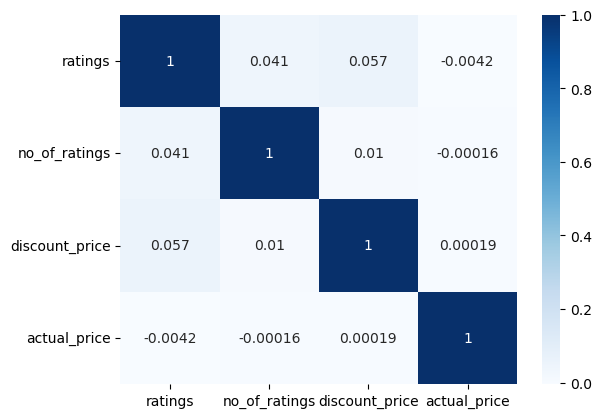

In [12]:
# Use price as dependent and select another appropriate variable to predict the output. 
c_corr = combined_df.corr()
#join_corr
sns.heatmap(c_corr, annot=True, cmap="Blues")

Create a Regplot/Scatterplot to demonstrate the relationship between our dependent and independent variable. 

<Axes: xlabel='no_of_ratings', ylabel='ratings'>

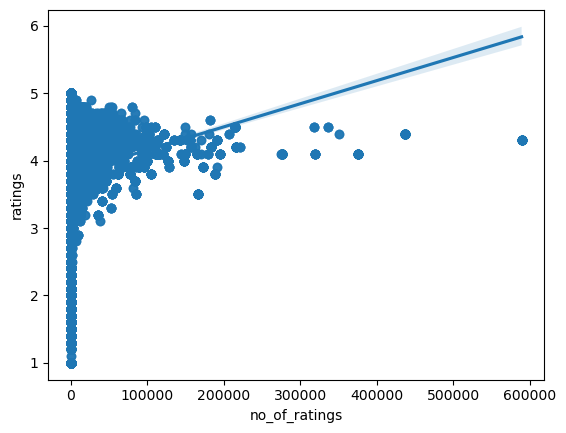

In [13]:
# Check the relationship between the selected variables
sns.regplot(x = "no_of_ratings",
            y = "ratings",
            data = combined_df)

---
### Building the model
Split the data into training and test datasets - include the random_state argument:<br>
random_state = 25

In [14]:
# Split the data into train and test samples
train, test = train_test_split(combined_df,random_state=25)

Set both the independent variable and dependent variable - remember to check they are set correctly. Don't forget to add a constant to your independent variables. 

In [15]:
# Set the dependent variable and validate
dep = train["ratings"]
dep.head()

183423    4.0
91100     4.1
788924    4.1
946904    3.0
961831    1.0
Name: ratings, dtype: float64

In [16]:
# Set the independent variable and validate
ind = train["no_of_ratings"]
ind.head()

183423       2.0
91100     1152.0
788924      27.0
946904       1.0
961831       1.0
Name: no_of_ratings, dtype: float64

In [17]:
# Remember to add the constant 
ind = sm.add_constant(ind)
ind.head()

,const,no_of_ratings
183423,1.0,2.0
91100,1.0,1152.0
788924,1.0,27.0
946904,1.0,1.0
961831,1.0,1.0


Now generate the model along with a summary output. 

In [18]:
# Fit the model and produce the summary
model = sm.OLS(dep,ind).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                ratings   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     817.2
Date:                Tue, 10 Mar 2026   Prob (F-statistic):          1.41e-179
Time:                        15:05:06   Log-Likelihood:            -5.5696e+05
No. Observations:              489488   AIC:                         1.114e+06
Df Residuals:                  489486   BIC:                         1.114e+06
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             3.8136      0.001   3518.110      0.000       3.812       3.816
no_of_ratings   3.38e-06   1.18e-07     28.586      0.000    3.15e-06    3.61e-06
==============================================================================
Omnibus:                   113644.485   Durbin-Watson:                   1.998
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           314657.044
Skew:                          -1.236   Prob(JB):                         0.00
Kurtosis:                       6.053   Cond. No.                     9.21e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 9.21e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

--- 
### Communicating the results. 
You will now analyse the model and communicate the results. What do the following outputs tell you about the model

- R-Squared: 
- F-Statistic: 
- Prob (F-Statistic):
- P-Value:
- Coefficient:
- Constant:

Now lets test the model output - remember to add a constant to your test data. 

In [19]:
# Set the test sample independent variable and use the model to predict the variable, using the test dataset 
test_ind = test[["ratings"]]
test_ind = sm.add_constant(test_ind)
output = model.predict(test_ind)

Finally, add a predicted column to your test dataset, where you have your prediction shown, alongside your actual values for your dependent variable. 

In [20]:
# Add the predicted values to our test dataframe to compare actual with predicted. 
test["predicted"] = output
test[["no_of_ratings","ratings","predicted"]]
#test = pd.to_csv("outputdata")

,no_of_ratings,ratings,predicted
81891,11.0,4.1,3.813648
1071291,22.0,3.9,3.813648
370321,2571.0,4.2,3.813649
801178,3.0,5.0,3.813651
719633,2.0,4.5,3.813650
...,...,...,...
459852,4.0,4.0,3.813648
705655,4.0,2.8,3.813644
830847,2.0,4.5,3.813650
584824,76.0,3.7,3.813647


Now you have genereated some predictions with the test data, explain the output by way of the formula Y = mX + C

---
### Stretch task
Create a new dataframe with some example data, and generate some predictions using your model.

--- 

In [21]:
# Create a new dataframe

In [22]:
# Generate  predictions

In [23]:
# Generate results in the dataframe, based on new dataset. 

--- 
### Operationalise
In the real world, this is where you would draft a report, deliver briefings, implement with automation on production level servers, produce technical documentation and build this into your BAU process. This being a fictional company, the ever grateful management have granted you paid leave for all your hard work and have volunteered to take on this burden themselves. Congratulations and well done!